In [57]:
import pandas as pd
import time
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.metrics import r2_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [58]:
data_path = "student-lifestyle-and-stress-dataset.csv"

df = pd.read_csv(data_path)

df.head(10)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1
5,college,4.914849,NaN,2.141137,85.144095,3.0,5.0,5.0,0
6,college,6.621709,5.261762,4.879102,NaN,4.0,7.0,7.0,0
7,college,6.357065,2.827955,6.198479,74.180341,7.0,8.0,6.0,0
8,college,8.085219,5.043731,4.660604,89.564367,3.0,2.0,7.0,0
9,college,4.627502,4.743084,5.579822,95.794315,5.0,5.0,10.0,0


In [59]:
# Reading Null Data
print(df.shape)
print(f"Reading Missing Values : {df.isnull().sum().max()}")

(25500, 9)
Reading Missing Values : 1333


Missing Values
Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
dtype: int64


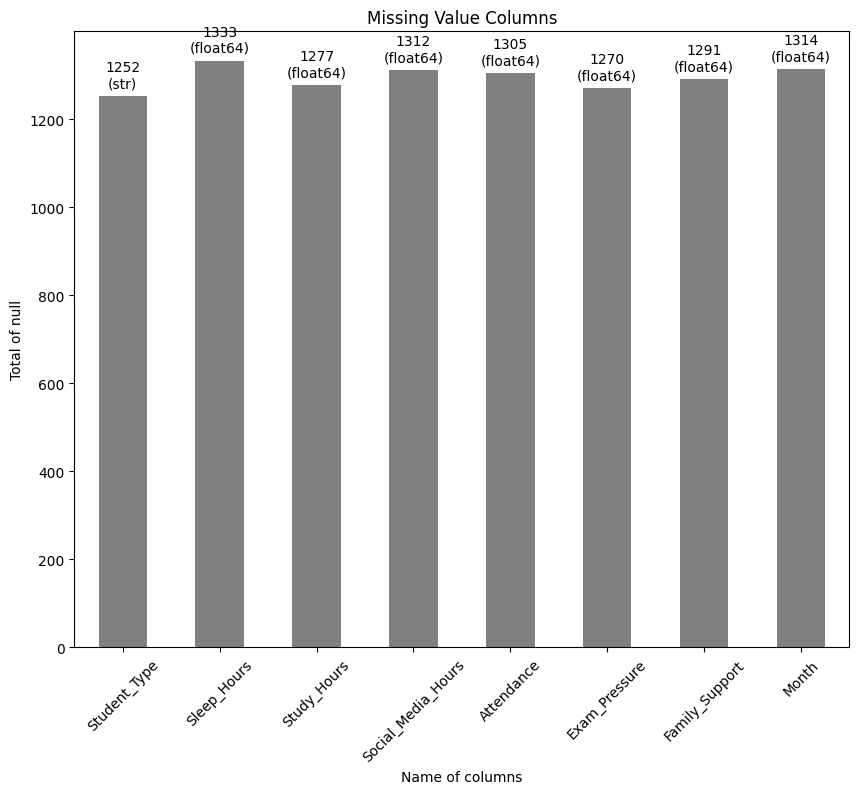

In [60]:
missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print("Missing Values")

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,8))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=45)
plt.show()

In [61]:

num_cols_impute = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours',
                   'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']

num_imputer = SimpleImputer(strategy='median')

df[num_cols_impute] = num_imputer.fit_transform(df[num_cols_impute])

cat_imputer = SimpleImputer(strategy='most_frequent')

df[['Student_Type']] = cat_imputer.fit_transform(df[['Student_Type']])

print("Fixing Missing Values =", df.isnull().sum().max())

Fixing Missing Values = 0


In [62]:
# Preprocessing 

dfe = df.copy()

print(dfe['Student_Type'].unique())

dfe['Student_Type'] = dfe['Student_Type'].map({'school' : 0, 'college' : 1, 'working_student' : 2})

<StringArray>
['school', 'college', 'working_student']
Length: 3, dtype: str


In [63]:
dfe.dtypes

Student_Type            int64
Sleep_Hours           float64
Study_Hours           float64
Social_Media_Hours    float64
Attendance            float64
Exam_Pressure         float64
Family_Support        float64
Month                 float64
Stress_Level            int64
dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

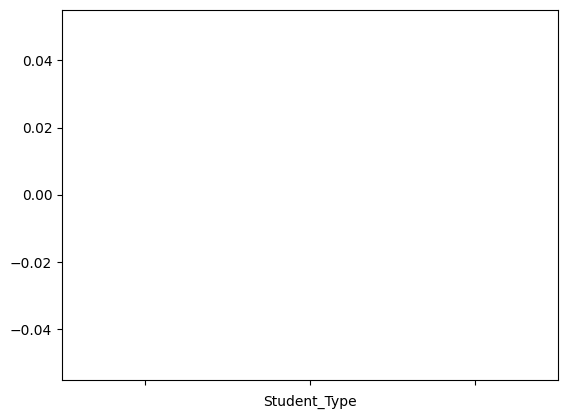

In [64]:
# Data visualtization EDA

label = ['School', 'College', 'Working_Student']

filtered_label = df['Student_Type'].value_counts().reindex(label).plot.bar(color=['black', 'red', 'gray'])
filtered_label.bar_label(filtered_label.containers[0], labels=label, label_type='center', color='white', rotation=90, fontsize=16, fontweight='bold')

filtered_label.set_xticklabels([])

plt.show


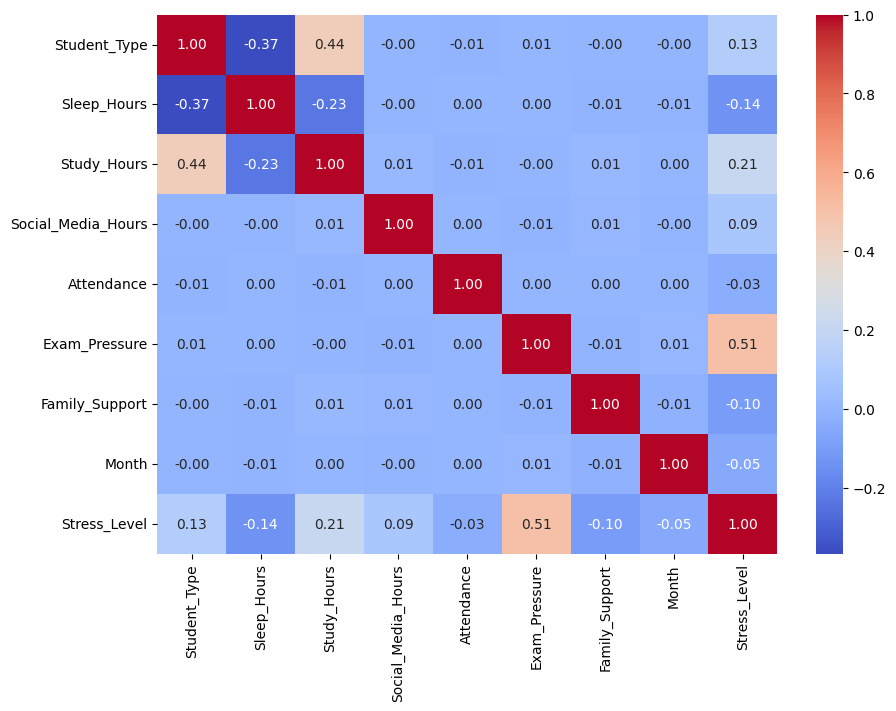

In [65]:
plt.figure(figsize=(10, 7))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f') 

plt.show()